In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [21]:
import pandas as pd
import numpy as np
import torch
import random
import seaborn as sns
import matplotlib.pyplot as plt
from torch import nn
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import sys, accelerate
print(sys.executable)
print(accelerate.__version__)


c:\Users\belw2\Desktop\ALL\ML && DL\venv\Scripts\python.exe
1.13.0


In [22]:
# --- CONFIGURATION ---
MODEL_NAME = "microsoft/deberta-v3-base" # Upgraded to BASE
MAX_LEN = 256                            # Kept at 128 for speed with the larger model
BATCH_SIZE = 16                          # Lowered to 16 to prevent memory crashes
GRADIENT_ACC_STEPS = 2                   # 16 * 2 = 32 effective batch size
EPOCHS = 3                               # 2 epochs is plenty for 64k rows
LEARNING_RATE = 2e-5

In [23]:
# --- 1. DATA PREPARATION ---
try:
    # Read from local files in the same folder as this notebook
    df_train_full = pd.read_csv("train.csv")
    df_test = pd.read_csv("test.csv")
except FileNotFoundError:
    print("Error: train.csv or test.csv not found in the local folder.")
    raise

# NEW: Remove duplicate reviews to prevent "fake" high scores
initial_count = len(df_train_full)
df_train_full = df_train_full.drop_duplicates(subset=['sentence'])
print(f"Removed {initial_count - len(df_train_full)} duplicate reviews.")

# Clean empty rows
df_train_full = df_train_full.dropna(subset=['sentence', 'sentiment'])

# Map string labels to integers
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
if df_train_full['sentiment'].dtype == 'O':
    df_train_full['label'] = df_train_full['sentiment'].map(label_map)
else:
    df_train_full['label'] = df_train_full['sentiment']

# Split train into Train/Validation
train_df, val_df = train_test_split(
    df_train_full, 
    test_size=0.1, 
    random_state=42, 
    stratify=df_train_full['label']
)

# Convert to Hugging Face format
ds_train = Dataset.from_pandas(train_df)
ds_val = Dataset.from_pandas(val_df)
ds_test = Dataset.from_pandas(df_test)

Removed 11957 duplicate reviews.


label
2    24629
0    20817
1     6597
Name: count, dtype: int64


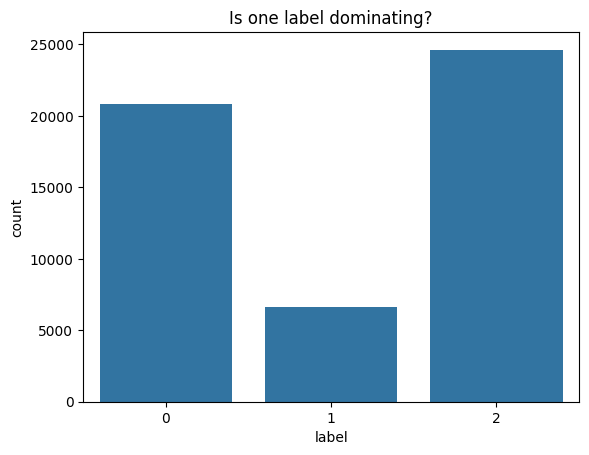

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check the counts in your training data
print(df_train_full['label'].value_counts())

# Visual check
sns.countplot(x='label', data=df_train_full)
plt.title("Is one label dominating?")
plt.show()

In [25]:
# --- 2. TOKENIZATION ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_function(examples):
    col_name = 'text' if 'text' in examples else 'sentence'
    return tokenizer(examples[col_name], truncation=True, padding="max_length", max_length=MAX_LEN)

encoded_train = ds_train.map(preprocess_function, batched=True)
encoded_val = ds_val.map(preprocess_function, batched=True)
encoded_test = ds_test.map(preprocess_function, batched=True)

Map: 100%|██████████| 16000/16000 [00:04<00:00, 3793.14 examples/s]


In [26]:
# --- 3. METRIC FUNCTION ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"f1_macro": f1_score(labels, predictions, average="macro")}

In [27]:
# --- DEVICE CHECK ---
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device index:", torch.cuda.current_device())
    print("Current device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("Running on CPU – no CUDA GPU detected by PyTorch.")

Torch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
Current device index: 0
Current device name: NVIDIA GeForce RTX 5070


In [28]:
import os
 # Fixes the "process just got forked" warning
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# --- 4. MODEL SETUP ---
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

# Explicitly set device to CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Using device:", device)

# Fix for DeBERTa v3 warning
model.config.keys_to_ignore_at_inference = ["source_embeddings"]

args = TrainingArguments(
    output_dir=f"checkpoints_{MODEL_NAME.replace('/', '-')}",
    bf16=True,                       # Use Mixed Precision for speed
    fp16=False,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACC_STEPS, 
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    num_train_epochs=EPOCHS,
    
    # NEW: Stability Improvements
    # warmup_ratio=0.1,                # 10% of training spent ramping up
    # lr_scheduler_type="cosine",      # Smoother learning rate drop
    
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
    # dataloader_num_workers=2
)


# 1. Calculate weights based on your cleaned training data
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df_train_full['label']),
    y=df_train_full['label']
 )  # Note: no trailing comma here

# 2. Convert to tensor with correct precision for bf16/fp16
class_weights = torch.tensor(weights, dtype=torch.float32) 

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # FIX: Pull the device from the labels tensor instead of model.device
        # This works even if the model is wrapped in DataParallel
        current_device = labels.device
        
        # Match device and precision
        weight_tensor = class_weights.to(device=current_device, dtype=logits.dtype) 
        
        # Use weight + label smoothing for Macro F1 optimization
        loss_fct = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=0.1)
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss
        
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=encoded_train,
    eval_dataset=encoded_val,
    compute_metrics=compute_metrics
)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 39595.32it/s]
DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.

Using device: cuda


In [29]:
# --- 5. TRAINING ---
print("Starting training with DeBERTa-v3-Base...")
trainer.train()

Starting training with DeBERTa-v3-Base...


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.000000,nan,0.190476
2,0.000000,nan,0.190476
3,0.000000,nan,0.190476


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.20it/s]
There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.la

TrainOutput(global_step=4392, training_loss=24178.683060109288, metrics={'train_runtime': 1206.1029, 'train_samples_per_second': 116.502, 'train_steps_per_second': 3.641, 'total_flos': 1.848589090343424e+16, 'train_loss': 24178.683060109288, 'epoch': 3.0})

Generating predictions...


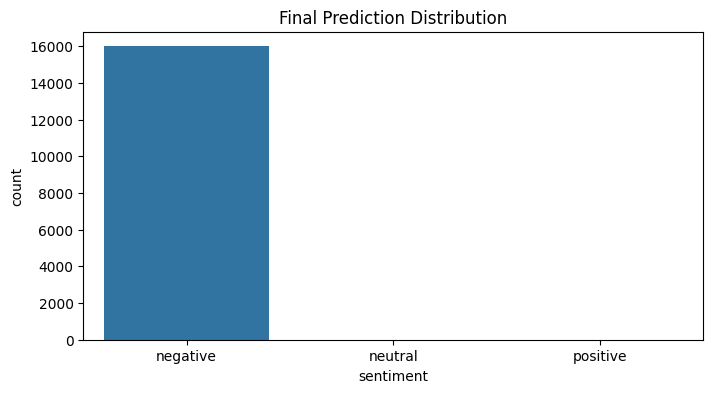

Process Complete! submission.csv is ready.


In [30]:
# --- 6. PREDICTION & SUBMISSION ---
print("Generating predictions...")
predictions = trainer.predict(encoded_test)
preds = np.argmax(predictions.predictions, axis=-1)

# Map integers back to strings
int_to_label = {0: 'negative', 1: 'neutral', 2: 'positive'}
pred_strings = [int_to_label[p] for p in preds]

submission = pd.DataFrame({'id': df_test['id'], 'sentiment': pred_strings})
submission.to_csv("submission.csv", index=False)

# Visualize final results
plt.figure(figsize=(8,4))
sns.countplot(x='sentiment', data=submission, order=['negative', 'neutral', 'positive'])
plt.title("Final Prediction Distribution")
plt.show()

print("Process Complete! submission.csv is ready.")